# Trabalho 5

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# local imports
sys.path.append(os.path.abspath(r"../util/"))


from geometry import Segment, Pose, Angle
from robot import Robot
from maps import ObstacleMap, OccupancyGrid
from range_finder import RangeFinders


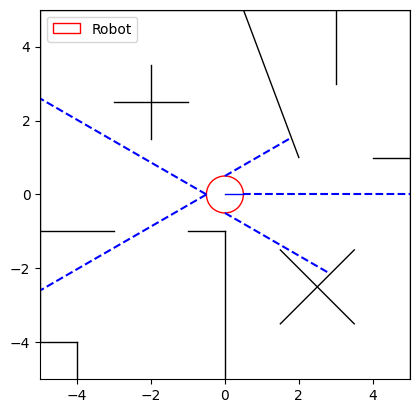

In [42]:
obstacle_map = ObstacleMap(
    [
        Segment((-5, 5), (5, 5)),
        Segment((5, -5), (5, 5)),
        Segment((-5, 5), (-5, -4)),

        Segment((-5, -4), (-4, -4)),
        Segment((-4, -5), (-4, -4)),
        Segment((-5, -1), (-3, -1)),

        Segment((-3, 2.5), (-1, 2.5)),
        Segment((-2, 1.5), (-2, 3.5)),
        Segment((0.5, 5), (2, 1)),

        Segment((3, 3), (3, 5)),
        Segment((4, 1), (5, 1)),
        Segment((-1, -1), (0, -1)),

        Segment((0, -1), (0, -5)),
        Segment((1.5, -1.5), (3.5, -3.5)),
        Segment((1.5, -3.5), (3.5, -1.5)),
    ],
    x_lims=(-5, 5),
    y_lims=(-5, 5)
)

occupancy_grid = OccupancyGrid([-5,5], [-5,5], 0.5)

robot = Robot(
    Pose(0, 0, Angle.from_deg(0.)), 
    sensors = [
        RangeFinders([
            Pose(0.5, 0, Angle(0.)),
            Pose(0, 0.5, Angle(np.pi/6)),
            Pose(0, -0.5, Angle(- np.pi/6)),
            Pose(-0.5, 0, Angle(np.pi - np.pi/6)),
            Pose(-0.5, 0, Angle(np.pi + np.pi/6)),
        ])
    ]
)
robot.measure(obstacle_map)

f = plt.figure()
ax = f.gca()

obstacle_map.draw(ax)
robot.draw(ax, r = 0.5)